MNIST Fashion Classification using ANN

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# load the fashion mnist dataset
mnist_data=tf.keras.datasets.fashion_mnist

In [4]:
(train_images,train_labels),(test_images,test_labels)=mnist_data.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


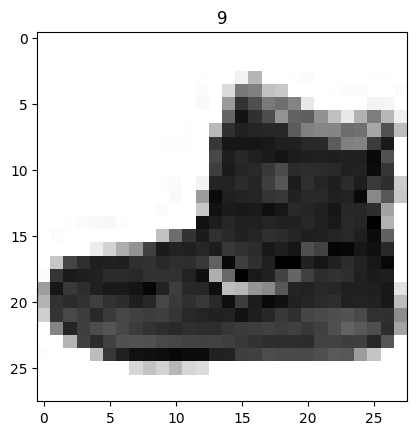

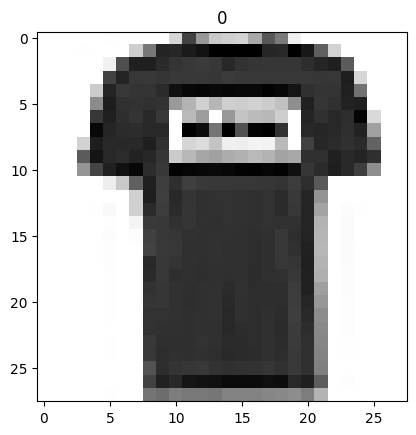

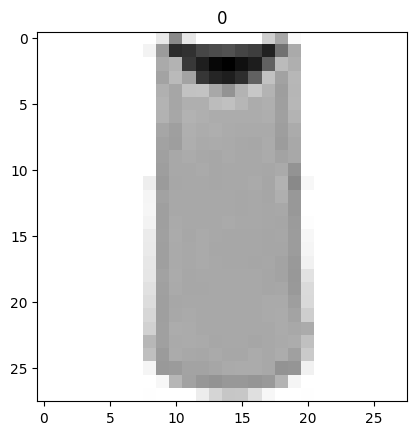

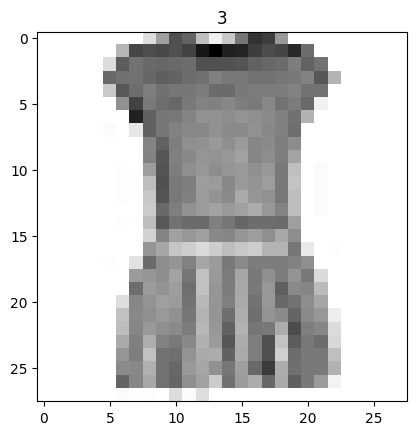

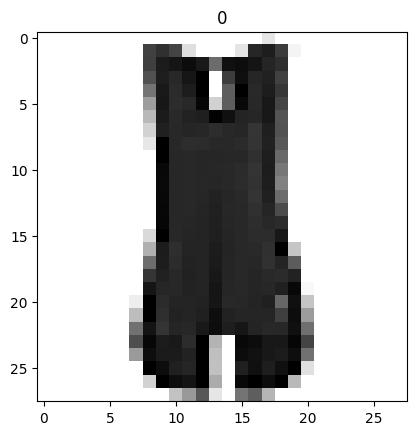

In [7]:
for i in range(5):
    plt.imshow(train_images[i],cmap='binary')
    plt.title(train_labels[i])
    plt.show()


In [8]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [9]:
# normalize the data
train_images=train_images/255
test_images=test_images/255

In [12]:
#build the ANN model
model= tf.keras.Sequential(
    [ 
        #ANN works with 1D so reshape/flatten
        tf.keras.Input(shape=(28,28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512,activation='relu'),
        tf.keras.layers.Dense(256,activation='relu'),
        tf.keras.layers.Dense(128,activation='relu'),
        tf.keras.layers.Dense(64,activation='relu'),
        tf.keras.layers.Dense(10,activation='softmax')
    ])

In [ ]:
# compile the model
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [14]:
# train the model
history= model.fit(train_images,train_labels,epochs=20,validation_split=0.2)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8166 - loss: 0.5099 - val_accuracy: 0.8482 - val_loss: 0.4257
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8593 - loss: 0.3796 - val_accuracy: 0.8572 - val_loss: 0.3811
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8745 - loss: 0.3410 - val_accuracy: 0.8752 - val_loss: 0.3304
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8849 - loss: 0.3119 - val_accuracy: 0.8673 - val_loss: 0.3582
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8902 - loss: 0.2929 - val_accuracy: 0.8840 - val_loss: 0.3264
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8965 - loss: 0.2762 - val_accuracy: 0.8793 - val_loss: 0.3428
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9001 - loss: 0.2676 - val_accuracy: 0.8838 - val_loss: 0.3204
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9058 - los

In [15]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,725,152 (6.58 MB)

 Trainable params: 575,050 (2.19 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,150,102 (4.39 MB)

In [16]:
# Predict the model
predictions=model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


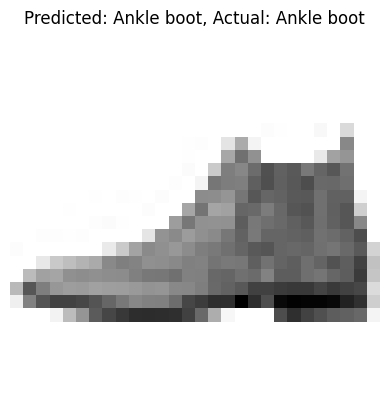

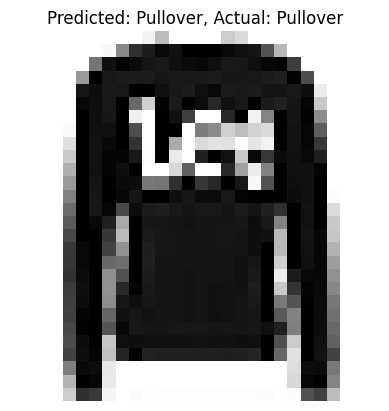

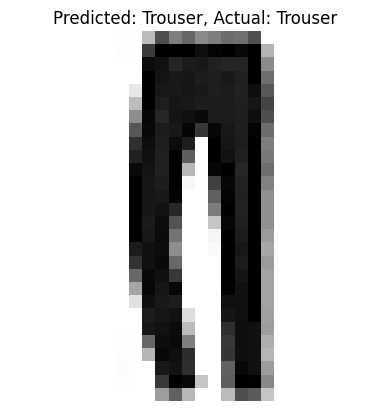

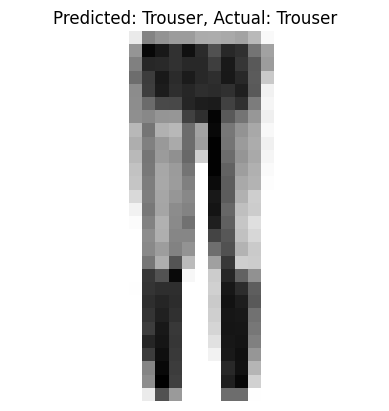

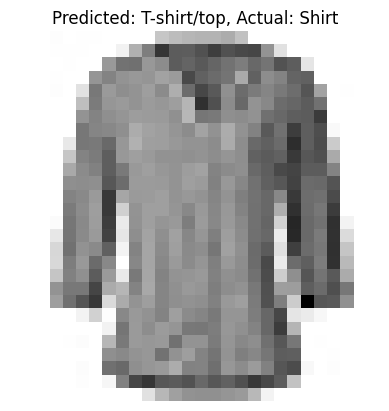

In [22]:
# plot 5 predictions with images
for i in range(5):
    plt.imshow(test_images[i].reshape(28,28),cmap='binary')
    plt.title(f"Predicted: {class_names[np.argmax(predictions[i])]}, Actual: {class_names[test_labels[i]]}")
    plt.axis('off')
    plt.show()

In [26]:
print(predictions)

[[1.6794188e-07 2.5311305e-05 2.0516941e-07 ... 1.2840721e-03
  7.2913413e-09 9.9782950e-01]
 [4.4056374e-06 3.4246739e-10 9.8901421e-01 ... 4.7002603e-11
  2.9861909e-08 3.8460489e-12]
 [0.0000000e+00 1.0000000e+00 2.8619707e-29 ... 0.0000000e+00
  4.1077597e-27 0.0000000e+00]
 ...
 [1.8764499e-18 2.5966691e-34 1.1456838e-15 ... 2.7813603e-18
  1.0000000e+00 1.1160237e-22]
 [0.0000000e+00 1.0000000e+00 2.0371320e-25 ... 0.0000000e+00
  3.5213192e-21 0.0000000e+00]
 [4.2462377e-13 7.1052896e-18 8.3642576e-10 ... 1.1160309e-05
  4.7338820e-11 1.4000547e-06]]


In [24]:
predicted_label=np.argmax(predictions)

In [27]:
pred_labels=[]
for item in predictions:
    pred_labels.append(np.argmax(item))

In [28]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay,confusion_matrix,classification_report
accuracy_score(test_labels,pred_labels)

0.8865

In [29]:
cm=confusion_matrix(test_labels,pred_labels)

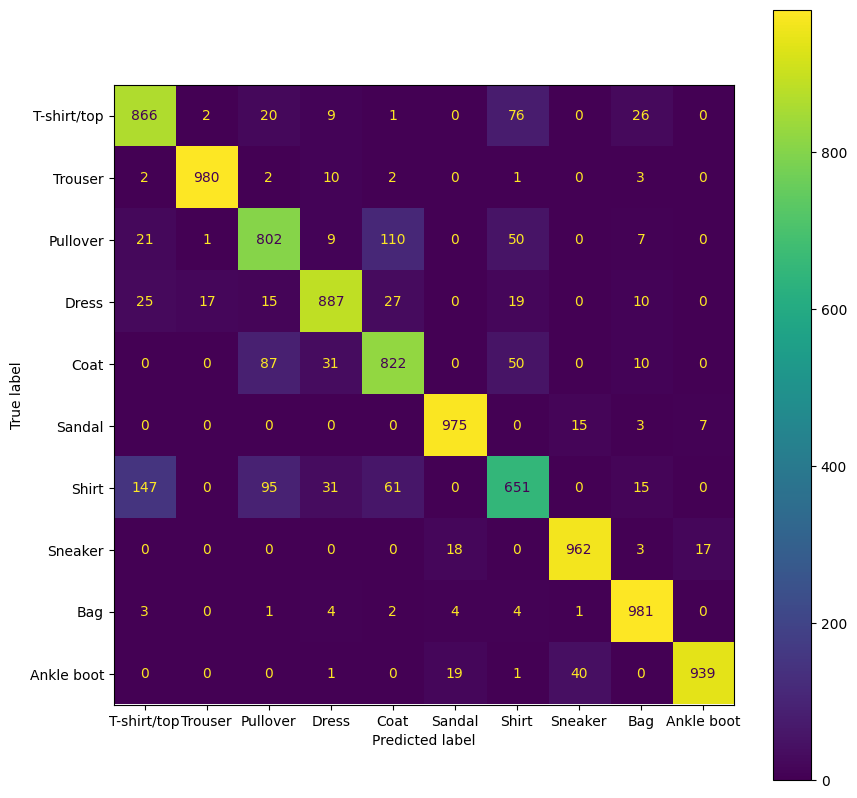

In [32]:
fig,ax=plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay(cm,display_labels=class_names).plot(ax=ax)

In [31]:
print(classification_report(test_labels,pred_labels,target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.81      0.87      0.84      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.78      0.80      0.79      1000
       Dress       0.90      0.89      0.90      1000
        Coat       0.80      0.82      0.81      1000
      Sandal       0.96      0.97      0.97      1000
       Shirt       0.76      0.65      0.70      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.93      0.98      0.95      1000
  Ankle boot       0.98      0.94      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

